<center><h1>MovieLens</h1></center>

In [1]:
from src import *
import src
import numpy as np
from importlib import reload
import pandas as pd
reload(src)
import matplotlib 
import matplotlib.pyplot as plt
from math import sqrt

import warnings
warnings.filterwarnings('ignore')

#matplotlib.use("pgf")
#matplotlib.rcParams.update({
#    "pgf.texsystem": "pdflatex",
#    'font.family': 'serif',
#    'text.usetex': True,
#    'pgf.rcfonts': False,
#})

In [2]:
userColumn='userId'
itemColumn='movieId'
ratingColumn='rating'

In [3]:
path_100k = 'data/raw/movielens/100K/ml-100k/u.data'
path_g_100k = 'data/raw/movielens/100K/movies.dat'

path_20m = 'data/raw/movielens/20M/ml-20m/ratings.csv'
path_g_20m = 'data/raw/movielens/20M/ml-20m/movies.csv'

In [4]:
loader = DataLoader(file_path='data/raw/movielens/100K/ml-100k/u.data',
                    separator='\t',
                    header=['userId', 'movieId', 'rating', 'timestamp'],
                    genre_data_path='data/raw/movielens/100K/movies.dat',
                    genre_data_separator='::',
                    genre_data_header=['itemID', 'itemName', 'genres'],
                    genre_item_column='itemID',
                    genre_genre_column='genres',
                    genre_genre_separator='|',
                    genre_data_encoding='ISO-8859-1'
                    )

24/09/08 18:12:13 WARN Utils: Your hostname, david-Nitro resolves to a loopback address: 127.0.1.1; using 192.168.15.14 instead (on interface wlp9s0)
24/09/08 18:12:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/09/08 18:12:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [5]:
df = loader.load_data()
df_pandas = loader.convert_to_pandas(df)
genres_map = loader.get_genre_map()
#(train, test) = loader.train_test_separator(df)

In [ ]:
# df_pandas = pd.read_csv(path_20m)

In [ ]:
df_pandas.shape

In [6]:
df_pandas = df_pandas[df_pandas['rating'] >= 4]

In [7]:
df_pandas.shape

(55375, 4)

24/09/08 18:12:29 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [8]:

f = df_pandas['userId'].value_counts()

In [9]:
f_mantain = f[f >= 100].index.to_list()

In [10]:
df = df_pandas[df_pandas['userId'].isin(f_mantain)]

In [11]:
df.shape

(27905, 4)

In [12]:
df['userId'].value_counts()

userId
450    378
416    322
59     280
7      274
276    274
      ... 
394    101
398    100
342    100
210    100
751    100
Name: count, Length: 184, dtype: int64

## ALS

In [12]:
kfold = KFOLD(df, 'FC', userColumn, itemColumn, ratingColumn, genres_map)

24/09/08 18:12:41 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [13]:
results = kfold.run_cross_validation()

1) Running FC
******************************
Lambda = 0.0
Reseting metrics lists
********************
FAIRNESS MEASURE: kullback-leibler
=====1º Fold=====
Train/test spliting
Instantiating ALS...


24/09/08 18:12:42 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
24/09/08 18:12:44 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.37778193404196475
CALCULATING MACE
MACE = 0.050530299301367626
CALCULATING MAP
MAP = 0.004393115942028985
CALCULATING MRR
MRR = 0.004393115942028985
=====2º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.33158927784015674
CALCULATING MACE
MACE = 0.04668219127307326
CALCULATING MAP
MAP = 0.0
CALCULATING MRR
MRR = 0.0
=====3º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.3390763120249026
CALCULATING MACE
MACE = 0.048137585339635976
CALCULATING MAP
MAP = 0.010785455486542445
CALCULATING MRR
MRR = 0.010785455486542445
=====4º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.3781270676453367
CALCULATING MACE
MACE = 0.049524445018249395
CALCULATING MAP
MA

Calibrating...
CALCULATING MRMC
MRMC = 0.40687933267189125
CALCULATING MACE
MACE = 0.049524445018249395
CALCULATING MAP
MAP = 0.004589371980676328
CALCULATING MRR
MRR = 0.0048913043478260865
=====5º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.40344119920668114
CALCULATING MACE
MACE = 0.05107241954782358
CALCULATING MAP
MAP = 0.017814009661835748
CALCULATING MRR
MRR = 0.017814009661835748
Getting mean and stdev
MACE Mean = 0.04918938809602997
MACE Error = 0.0017922359218008517
MRMC Mean = 0.38400471179785645
MRMC Error = 0.031074570315982094
MAP Mean = 0.0075163906142167005
MAP Error = 0.006920010003855982
MRR Mean = 0.007576777087646652
MRR Error = 0.006889331625925352
Appending to results


******************************
Lambda = 0.1
Reseting metrics lists
********************
FAIRNESS MEASURE: kullback-leibler
=====1º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions

Calibrating...
CALCULATING MRMC
MRMC = 0.10694777253839179
CALCULATING MACE
MACE = 0.040264565288127475
CALCULATING MAP
MAP = 0.030984730848861296
CALCULATING MRR
MRR = 0.030829451345755703
=====4º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.10756895844304357
CALCULATING MACE
MACE = 0.04040193728817935
CALCULATING MAP
MAP = 0.04448757763975157
CALCULATING MRR
MRR = 0.0439246894409938
=====5º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.13260985576808304
CALCULATING MACE
MACE = 0.041404776740154164
CALCULATING MAP
MAP = 0.03050595238095238
CALCULATING MRR
MRR = 0.03080788474810214
Getting mean and stdev
MACE Mean = 0.040862275532224976
MACE Error = 0.0008410774441570148
MRMC Mean = 0.11370952582919129
MRMC Error = 0.011298597760576594
MAP Mean = 0.04157091097308489
MAP Error = 0.021661484810604106
MRR Mean = 0.

In [14]:
results

,Lambda,FairnessMeasure,Statistic,MACE,MRMC,MAP,MRR
0,0.0,kullback-leibler,mean,0.049189,0.361182,0.007516,0.007577
1,0.0,kullback-leibler,stdev,0.000802,0.010622,0.003095,0.003081
0,0.0,hellinger,mean,0.049189,0.723950,0.007516,0.007577
1,0.0,hellinger,stdev,0.000802,0.008378,0.003095,0.003081
0,0.0,pearson,mean,0.049189,0.384005,0.007516,0.007577
...,...,...,...,...,...,...,...
1,1.0,kullback-leibler,stdev,0.000073,0.002713,0.009957,0.010951
0,1.0,hellinger,mean,0.031090,0.487127,0.060400,0.061548
1,1.0,hellinger,stdev,0.000121,0.001391,0.008811,0.010096
0,1.0,pearson,mean,0.039148,0.112810,0.049169,0.050342


In [17]:
results.to_csv('results/movielens/result_movielens4.csv', index=False)

In [ ]:
results = pd.read_csv('results/movielens/result_movielens2.csv')

In [17]:
results

,Lambda,FairnessMeasure,Statistic,MACE,MRMC,MAP,MRR
0,0.0,kullback-leibler,mean,0.002596,0.362294,0.007932,0.007977
1,0.0,kullback-leibler,stdev,0.000091,0.013598,0.003061,0.003050
0,0.0,hellinger,mean,0.002596,0.725964,0.007932,0.007977
1,0.0,hellinger,stdev,0.000091,0.011083,0.003061,0.003050
0,0.0,pearson,mean,0.002596,0.384945,0.007932,0.007977
...,...,...,...,...,...,...,...
1,1.0,kullback-leibler,stdev,0.000108,0.002842,0.009852,0.010706
0,1.0,hellinger,mean,0.001680,0.486490,0.057271,0.058107
1,1.0,hellinger,stdev,0.000115,0.001087,0.008527,0.009647
0,1.0,pearson,mean,0.002205,0.112693,0.049562,0.050443


In [ ]:
tradeoff_weights = results['Lambda'].drop_duplicates().to_list()
mrmc_kl = results[(results['FairnessMeasure'] == 'kullback-leibler') & (results['Statistic'] == 'mean')]['MAP'].to_list()
mrmc_he = results[(results['FairnessMeasure'] == 'hellinger') & (results['Statistic'] == 'mean')]['MAP'].to_list()
mrmc_pe = results[(results['FairnessMeasure'] == 'pearson') & (results['Statistic'] == 'mean')]['MAP'].to_list()

# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(tradeoff_weights, mrmc_kl, marker='o', linestyle='-', color='b', label='Kullback-Leibler')
plt.plot(tradeoff_weights, mrmc_he, marker='s', linestyle='-', color='r', label='Hellinger')
plt.plot(tradeoff_weights, mrmc_pe, marker='^', linestyle='-', color='g', label='Pearson chi-quadrado')

plt.xlabel('λ')
plt.xticks(np.arange(0.0, 1.1, 0.1))
plt.ylabel('Mean rank miscalibration (MRMC)')
plt.title('MovieLens com ALS')
plt.legend()
plt.grid(True)
plt.show()


#### CRIANDO GRÁFICOS

In [21]:
def show_graphic(dataset_name, metric, title):
    short_metric = metric[metric.find('(')+1: metric.find(')')]
    tradeoff_weights = results['Lambda'].drop_duplicates().to_list()
    mrmc_kl = results[(results['FairnessMeasure'] == 'kullback-leibler') & (results['Statistic'] == 'mean')][short_metric].to_list()
    mrmc_he = results[(results['FairnessMeasure'] == 'hellinger') & (results['Statistic'] == 'mean')][short_metric].to_list()
    mrmc_pe = results[(results['FairnessMeasure'] == 'pearson') & (results['Statistic'] == 'mean')][short_metric].to_list()

    mrmc_he_err = results[(results['FairnessMeasure'] == 'hellinger') & (results['Statistic'] == 'stdev')][short_metric].to_list()
    mrmc_he_err = [std/sqrt(5) for std in mrmc_he_err]
    mrmc_kl_err = results[(results['FairnessMeasure'] == 'kullback-leibler') & (results['Statistic'] == 'stdev')][short_metric].to_list()
    mrmc_kl_err = [std/sqrt(5) for std in mrmc_kl_err]
    mrmc_pe_err = results[(results['FairnessMeasure'] == 'pearson') & (results['Statistic'] == 'stdev')][short_metric].to_list()
    mrmc_pe_err = [std/sqrt(5) for std in mrmc_pe_err]
    
    # Plotando o gráfico com barras de erro
    plt.figure(figsize=(10, 6))
    plt.errorbar(tradeoff_weights, mrmc_kl, yerr=mrmc_kl_err, marker='o', linestyle='-', color='b', label='Kullback-Leibler', capsize=5) 
    plt.errorbar(tradeoff_weights, mrmc_he, yerr=mrmc_he_err, marker='s', linestyle='-', color='r', label='Hellinger', capsize=5) 
    plt.errorbar(tradeoff_weights, mrmc_pe, yerr=mrmc_pe_err, marker='^', linestyle='-', color='g', label='Pearson chi-quadrado', capsize=5)
    
    # Configurando os rótulos e título
    plt.xlabel(r'$\lambda$')
    plt.ylabel(metric)
    plt.title(title)
    
    # Definindo os valores do eixo x para incrementar de 0.1 em 0.1
    plt.xticks(np.arange(0.0, 1.1, 0.1))
    
    plt.legend()
    plt.grid(True)
    #plt.savefig(f'results/{dataset_name}/graphs/{dataset_name}_{metric}.pgf'.replace(' ', '_'))
    plt.savefig(f'results/{dataset_name}/graphs/{dataset_name}_{metric}.pdf'.replace(' ', '_'), bbox_inches='tight')
    plt.show()
    


    

==========Mean Average Calibration Error (MACE)==========


ConversionError: Failed to convert value(s) to axis units: ['0,0', '0,1', '0,2', '0,30000000000000004', '0,4', '0,5', '0,6000000000000001', '0,7000000000000001', '0,8', '0,9', '1,0']

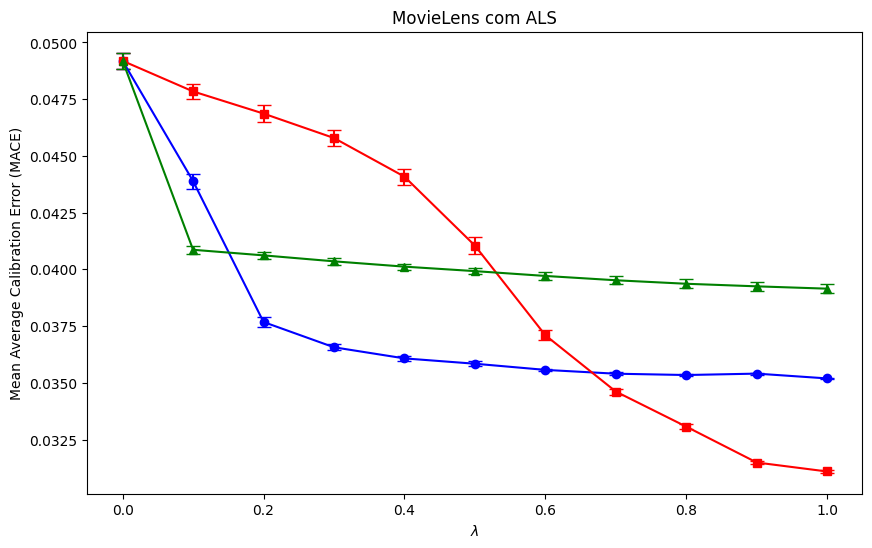

In [22]:
title = 'MovieLens com ALS'
for metric in ['Mean Average Calibration Error (MACE)', 'Mean Rank Miscalibration (MRMC)', 'Mean Average Precision (MAP)', 'Mean Reciprocal Rank (MRR)']:
    print('=' * 10 + metric + '=' * 10)
    show_graphic('movielens', metric, title)
    



In [ ]:
predictions_user_map

In [ ]:
distributions = Distributions(train.toPandas(), userColumn, itemColumn, genres_map)

In [ ]:
distributions.show_userProfileDist_userRecDist(predictions_user_map, 305)


# FBC-kNN

In [ ]:
df_genres = loader.genre_data

In [ ]:
df_genres

In [ ]:
df_expanded = df_genres['genres'].str.get_dummies(sep='|')

In [ ]:
df_final = pd.concat([df_genres[['item']], df_expanded], axis=1)

In [ ]:
df_final.index = df_final['item']

In [ ]:
df_mv_genres = df_final.drop(columns = ['item'])

In [ ]:
df_mv_genres

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
cosine_sim = cosine_similarity(df_mv_genres)

In [ ]:
df_cosine_sim = pd.DataFrame(cosine_sim, index = df_mv_genres.index, columns = df_mv_genres.index)

In [ ]:
df_cosine_sim

In [ ]:
similar_itens = list(df_cosine_sim.loc[1].sort_values(ascending=False).keys())[:102]
similar_itens.remove(1)
#rated_by_u = set(df_pandas[(df_pandas[userColumn] == 1) & (df_pandas[ratingColumn] > 0)][itemColumn].to_list())
#intersect = list(similar_itens.intersection(rated_by_u))[:101]


In [ ]:
def get_recommendatinon(movieId, userId, df_sim, df_ratings, k):
    similar_itens = list(df_sim.loc[movieId].sort_values(ascending=False).keys())[:k+2]
    similar_itens.remove(movieId)
    return similar_itens()


In [ ]:
#def get_recommendatinon(movieId, userId, df_sim, df_ratings, k):
#    similar_itens = set(df_sim.loc[movieId].sort_values(ascending=False).keys())
#    rated_by_u = set(df_ratings[(df_ratings[userColumn] == userId) & (df_ratings[ratingColumn] > 0)][itemColumn].to_list())
#    intersect = list(similar_itens.intersect(rated_by_u))[:k+1]
